In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score, roc_curve, auc

In [38]:
pd.set_option('display.max_columns', None)

In [39]:
data = pd.read_csv(r"C:\Users\USER\Downloads\breast cancer.csv", index_col = False)

In [68]:
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,0.07871,0.84865,0.90530,5.9835,86.20,0.006399,0.049040,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,1937.05,0.16220,0.62695,0.7119,0.2654,0.41915,0.11890
1,M,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,0.05667,0.54350,0.73390,3.3980,74.08,0.005225,0.013080,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1937.05,0.12380,0.18660,0.2416,0.1860,0.27500,0.08902
2,M,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,0.05999,0.74560,0.78690,4.5850,86.20,0.006150,0.040060,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.00,0.14440,0.42450,0.4504,0.2430,0.36130,0.08758
3,M,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,0.07875,0.49560,1.15600,3.4450,27.23,0.009110,0.061505,0.05661,0.01867,0.03596,0.008023,14.910,26.50,98.87,567.70,0.19010,0.62695,0.6869,0.2575,0.41915,0.12301
4,M,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,0.05883,0.75720,0.78130,5.4380,86.20,0.011490,0.024610,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.00,0.13740,0.20500,0.4000,0.1625,0.23640,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1326.3,0.111000,0.11590,0.24390,0.13890,0.1726,0.05623,0.84865,1.25600,5.9835,86.20,0.010300,0.028910,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,1937.05,0.14100,0.21130,0.4107,0.2216,0.20600,0.07115
565,M,20.13,28.25,131.20,1261.0,0.097800,0.10340,0.14400,0.09791,0.1752,0.05533,0.76550,2.43415,5.2030,86.20,0.005769,0.024230,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.00,0.11660,0.19220,0.3215,0.1628,0.25720,0.06637
566,M,16.60,28.08,108.30,858.1,0.084550,0.10230,0.09251,0.05302,0.1590,0.05648,0.45640,1.07500,3.4250,48.55,0.005903,0.037310,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.00,0.11390,0.30940,0.3403,0.1418,0.22180,0.07820
567,M,20.60,29.33,140.10,1265.0,0.117800,0.22862,0.28241,0.15200,0.2397,0.07016,0.72600,1.59500,5.7720,86.20,0.006522,0.061505,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.00,0.16500,0.62695,0.7855,0.2650,0.40870,0.12301


In [41]:
ten_cols = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

sec_cols = ['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst']

third_cols = ['perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst',
       'symmetry_worst', 'fractal_dimension_worst']

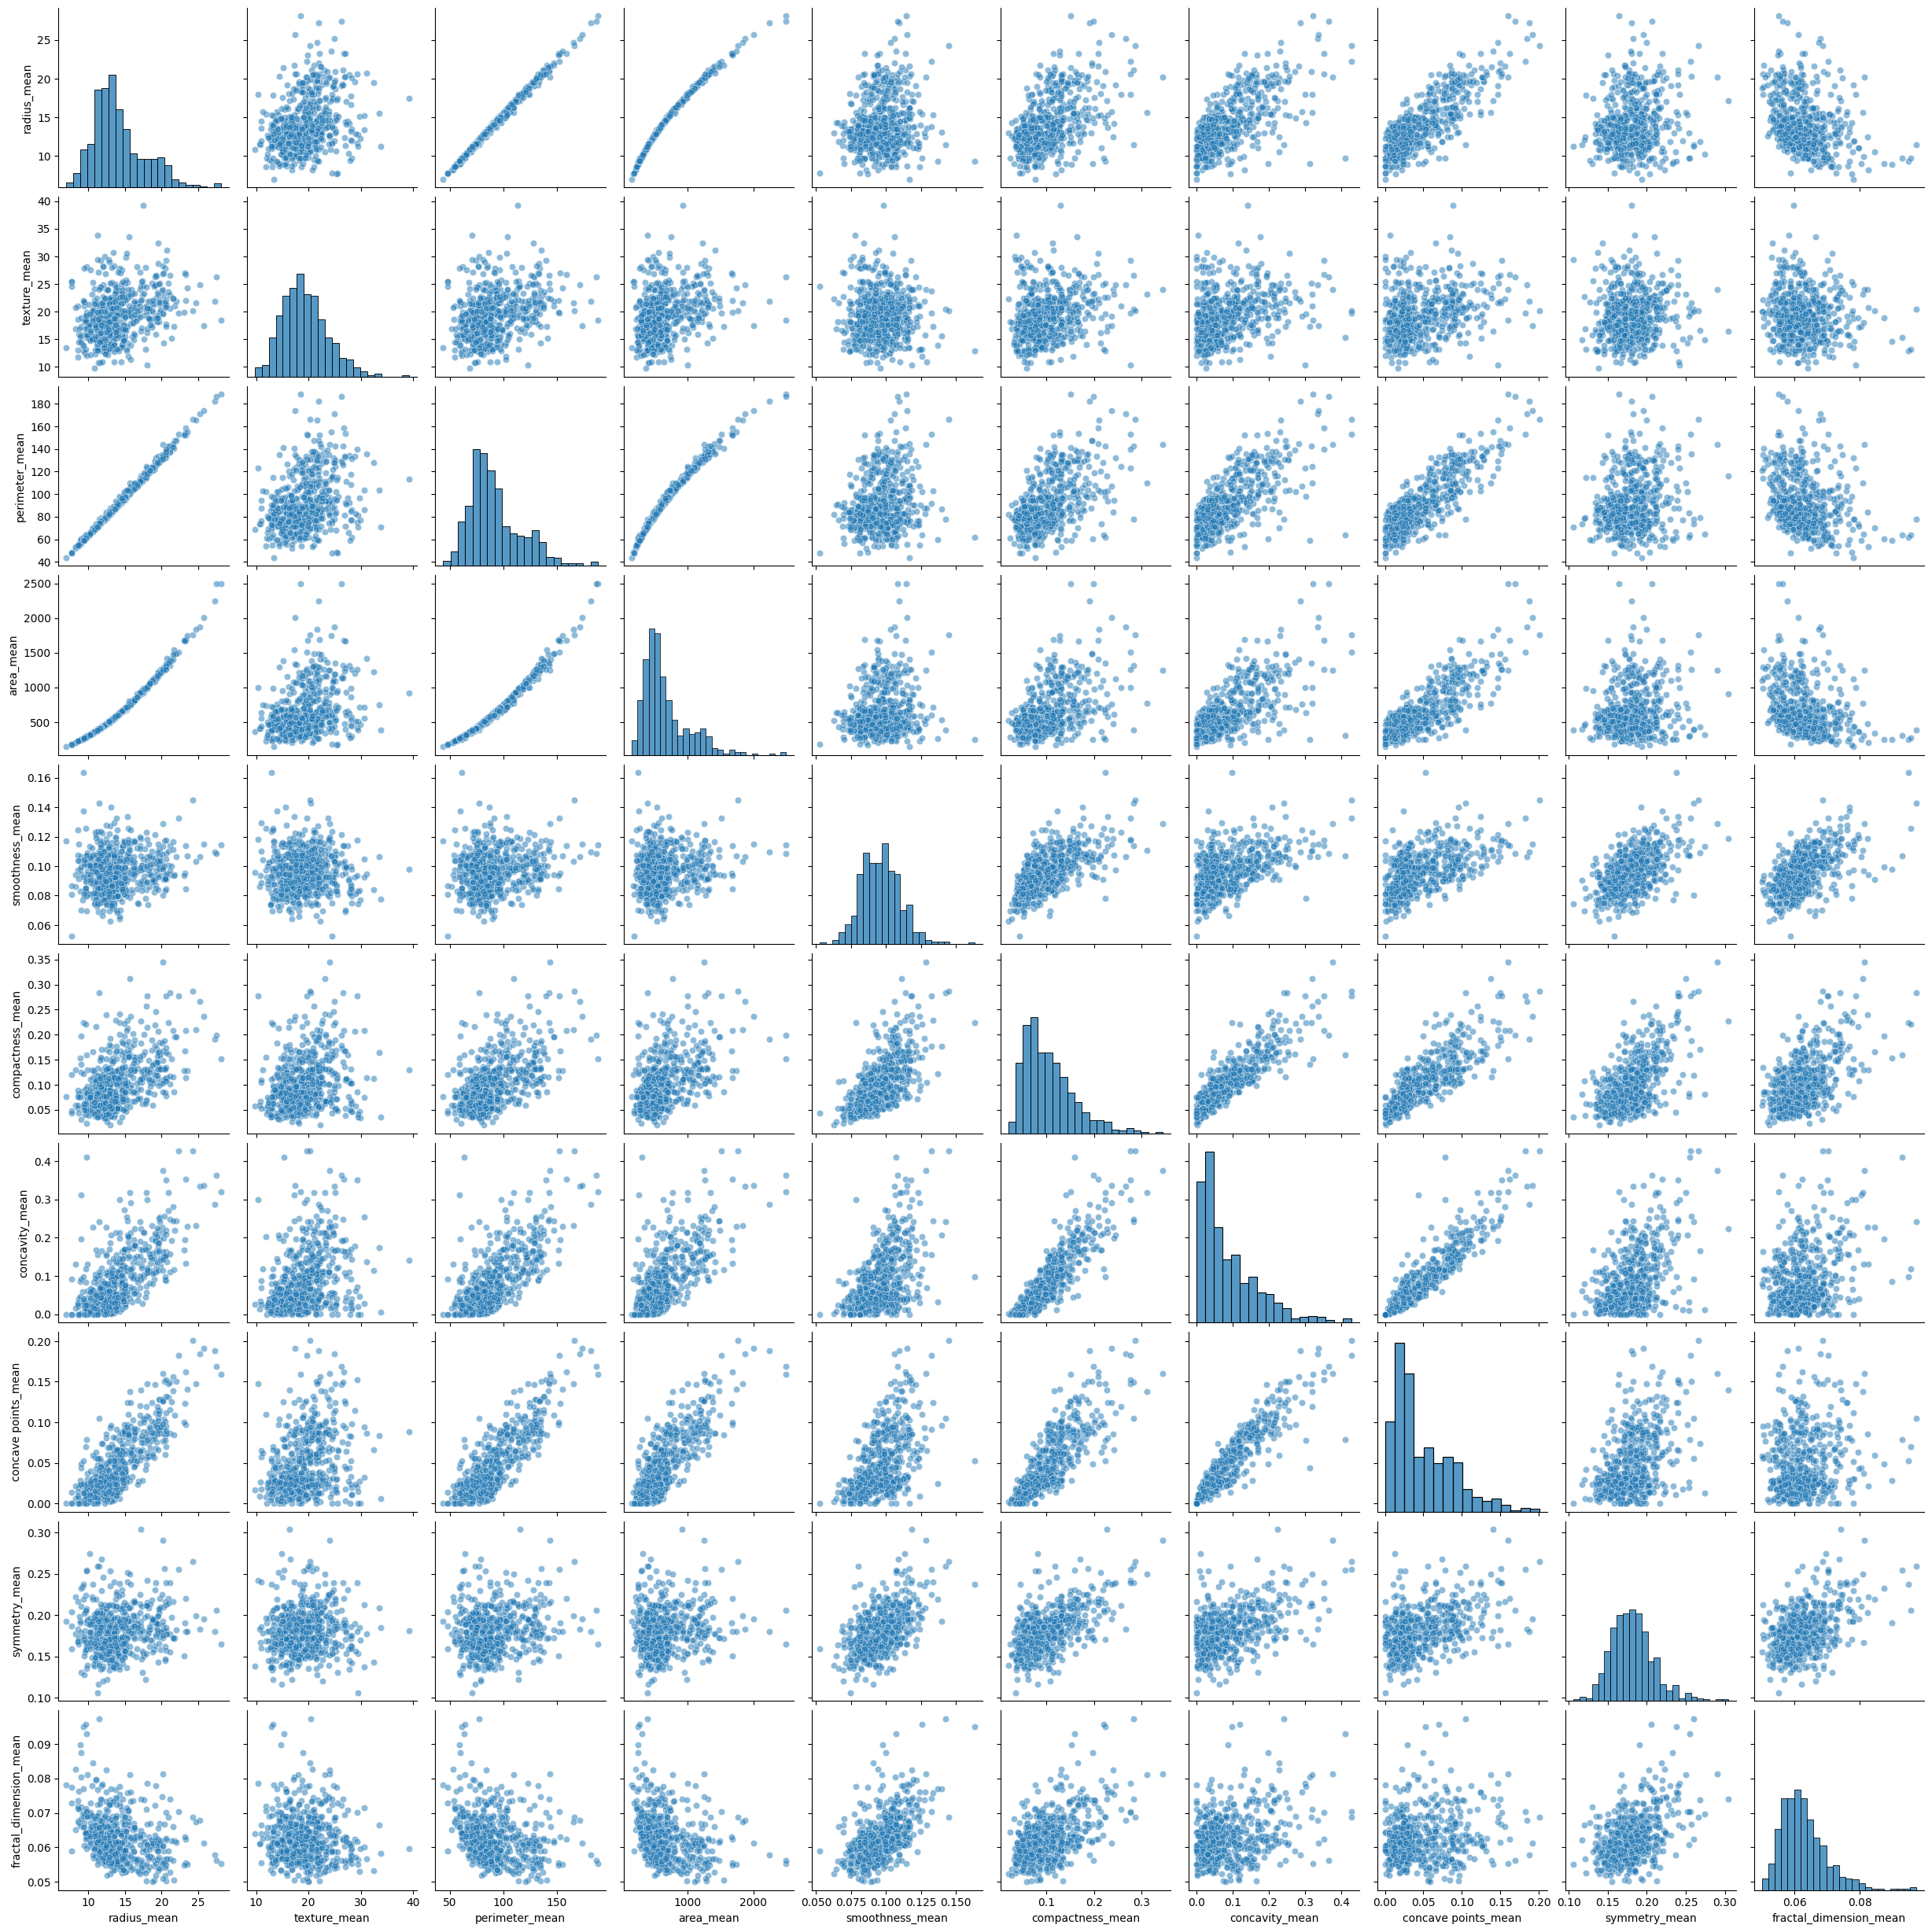

In [8]:
sns.pairplot(data = data[ten_cols], kind = 'scatter', plot_kws = {'alpha': 0.5})

In [50]:
data = data.drop(columns = ['id','Unnamed: 32'], axis = 1)

<Axes: xlabel='diagnosis', ylabel='count'>

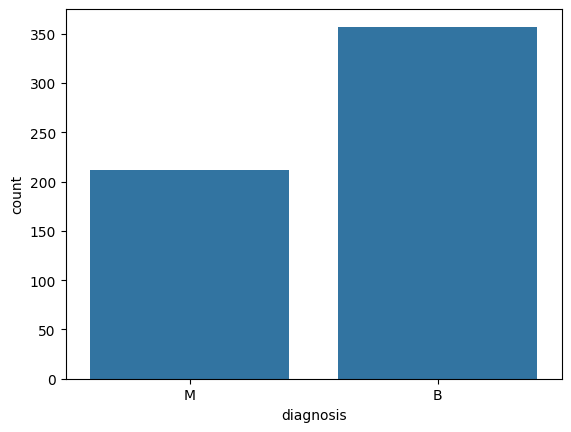

In [51]:
sns.countplot(data =data , x = data['diagnosis'])

In [52]:
all_cols = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst',
       'symmetry_worst', 'fractal_dimension_worst']

for i in all_cols:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)

    IQR = Q3 - Q1
    upperbound = Q3 + 1.5*IQR
    lowerbound = Q1  - 1.5 * IQR

    data[i] = data[i].clip(lowerbound, upperbound)

In [53]:
data.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [54]:
X = data.drop('diagnosis', axis = 1)
Y = data['diagnosis']


In [55]:
scaler = StandardScaler()
encoder = LabelEncoder()

Y= encoder.fit_transform(Y)  #1 malignant 0 benign

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 43)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train_scaled, Y_train)

y_pred = model.predict(X_test_scaled)
y_scores = model.predict_proba(X_test_scaled)[:, 1] 

accuracy = accuracy_score(Y_test, y_pred)
conf_matrix = confusion_matrix(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
roc_auc = roc_auc_score(Y_test, y_scores)


In [57]:
print("Simulated Metrics:")
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n {conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}") # from pro

Simulated Metrics:
Accuracy: 0.9649122807017544
Confusion Matrix:
 [[69  3]
 [ 1 41]]
Precision: 0.9318181818181818
Recall: 0.9761904761904762
F1 Score: 0.9534883720930233
ROC AUC: 0.9973544973544973


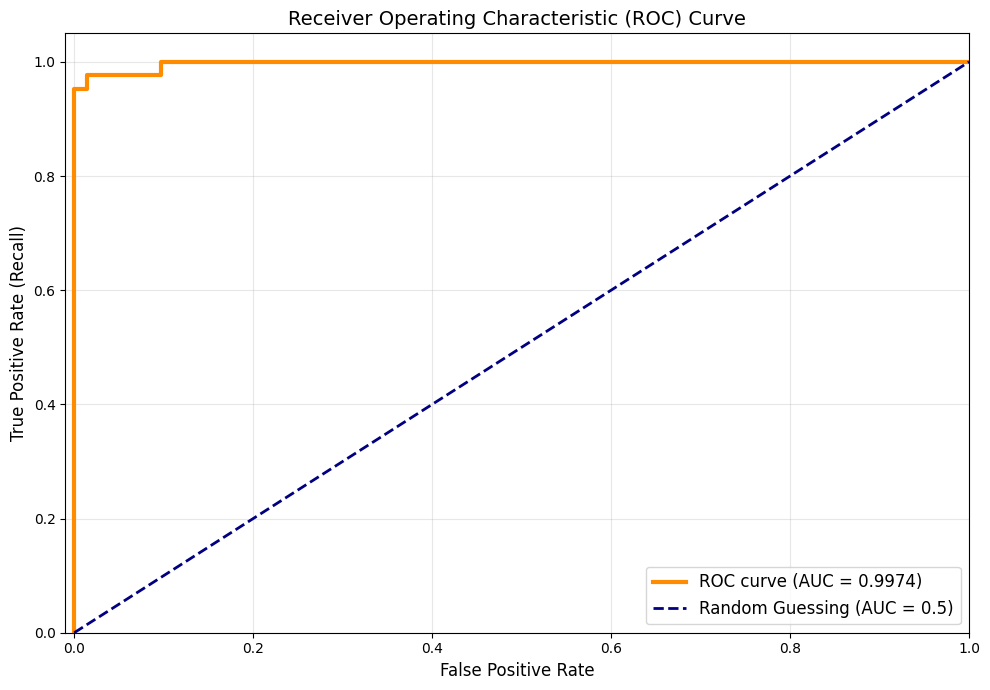

In [58]:
fpr, tpr, thresholds = roc_curve(Y_test, y_scores)
roc_auc = auc(fpr, tpr) # We can also calculate AUC from the curve

# 7. Plot the ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
def predict(new_data):
    new_data = np.asarray(new_data)
    new_data_reshaped = new_data.reshape(1,-1)

    scaled_data = scaler.transform(new_data_reshaped)
    prediction = model.predict(scaled_data)

    return prediction

new_sample_malignant = (17.82, 21.76, 117.50, 1008.3, 0.1067, 0.1284, 0.1648, 0.0912,
              0.1958, 0.0629, 0.5241, 1.289, 3.564, 58.73, 0.00812, 0.03145, 0.0421, 0.01583, 0.0221, 0.0034, 
              20.88, 30.12, 138.4, 1292.0, 0.1415, 0.3088, 0.3531, 0.1735, 0.3270, 0.0864) #actual diagnosis is malignant

new_sample_benign = (12.45, 17.88, 79.86, 492.1, 0.09581, 0.08862, 0.03904, 0.02562, 0.1783, 0.06206, 0.2563,
                     1.038, 1.686, 19.48, 0.006513, 0.01875, 0.02299, 0.01084, 0.01721, 0.002719, 13.74, 26.38, 89.04,
                     589.6, 0.1373, 0.2046, 0.1644, 0.08658, 0.2793, 0.07408) #actual diagnosis is benign

new_sample_benign_2 = (10.52, 16.34, 67.12, 345.5, 0.0872, 0.0567, 0.0201, 0.0115, 0.1601, 0.0592, 0.2101, 0.893, 1.451,
                       13.89, 0.0051, 0.0123, 0.0156, 0.0068, 0.0159, 0.0021, 11.48, 21.65, 73.68, 420.3, 0.1078, 0.1245,
                       0.0883, 0.0452, 0.2257, 0.0714)

input_values = [new_sample_malignant, new_sample_benign, new_sample_benign_2]
sample_names = ["Sample_1", "Sample 2", "Sample 3"]

for name, sample in zip(sample_names, input_values):
    
    prediction = "Malignant" if predict(sample)  == 1 else "Benign"
    print(f"{name} diagnosis: {prediction}")


Sample_1 diagnosis: Malignant
Sample 2 diagnosis: Benign
Sample 3 diagnosis: Benign


C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
